SMS Spam Detection - Supervisied Machine Learning Model - Classifiction

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

#sklearn library, feature_extraction.text module, tfidfvectorizer is a class

#computer can't deal with text

# 'feature.extraction.text' is a sub-module that we reach  TfidfVectorizer
# 'TfidfVectorizer' is an algorithm, the word itself is could be splitted to:
# 'Tf' & 'idf & 'Vectorizer'

# 'Tf' stands for 'Term Frequency' or which means "how word appears in a message"
# so if a one specific word, appeared in a message 3 times, and this message has 10 words,
# then the weight of this word is 3/10 or 0.3. it gives weights for words

# 'idf' stands for 'Inverse Document Frequency' or which means "how rare that specific word appears across all messages"
# so for each word, it checks it across all message, let's say we have 100 messages, and it captures the word 2 times, so it's a rare word
# and it calculates how rare it is by this formula: idf = log(all_msg/no_appears)
# if it appears much, the idf would be low, if it appears lil, it will be high

#
#finally, we mulitply both values of tf and idf as: tf*idf, then we get how rare this word is to that specific message we find word at
#the higher the number, the more valuable and unique the word is to that message
#the less the number of mulitplication, the more common and unimportant this word to that message

# so basically, this algorithm captures a word, check it through the one message, and check it across the whole messages it'll train on

# then we put all the values of the weights of every word in a vector: [0.1, 0.9, 0.2, 0.7, ...]

In [ ]:
#MultinomialNB is for mulitnomial Naive Bayes
# naive bayes is a famous algorithms that depends on probablity to classify data based on one feature
# it's multinomial cuz it depends on discrete data (weights/counts of appears and frequancies of words),
# so it doesn't recognize words, it doesn't notice patterns, it just counts on discrete data coming from TfidfVectorize

In [ ]:
#Loading and reading the data using pandas and function read_csv

df = pd.read_csv('/content/sms_spam_full.csv')

#the dataset contains 2 columns, label and message, and 200 row as 200 message and their labels

In [ ]:
# Drop empty or NaN messages



# .dropna is a pandas function that removes any row that misses the message. na is for Not Avaliable
# the subset=['message'] tells the function to drop from only the messages columns, and not get to the labels or the spam or ham column

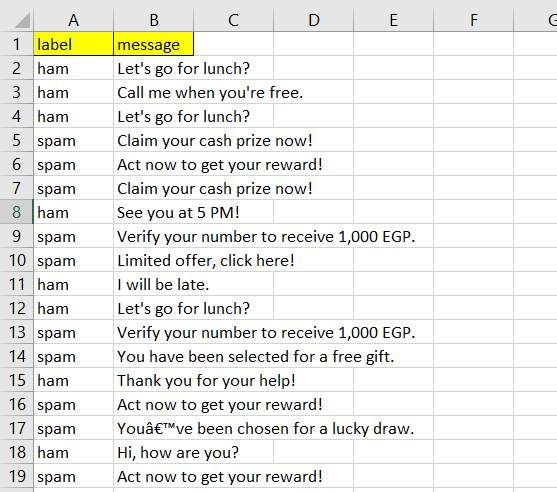

In [ ]:
# Ensure all messages are strings



#It converts every value in the message column into a string, just to make sure all messages are treated as text.
# .astype(datatype) is a function in Pandas that makes sure that the datatype between braces is applied for all rows in message column
#then we store it back again in the same variable/column after we made sure it's string

In [ ]:
#mapping labels of the data, ham values are mapped to 0, spam to 1

df['label_num'] = df['label'].map({'ham' : 0, 'spam' : 1})

# here, we created a new column in our dataset, that maps the values of the labels to a binary values 0 or 1, to make it easier for the computer to understand

In [ ]:
df.head()

,label,message,label_num
0,ham,Let's go for lunch?,0
1,ham,Call me when you're free.,0
2,ham,Let's go for lunch?,0
3,spam,Claim your cash prize now!,1
4,spam,Act now to get your reward!,1


In [ ]:
#split data

#x = df["message"] # here we save the questions, the messages themselves
#y = df["label_num"] # here we save the answers, spam or ham, but of course in binary form, 0 or 1, so the computer could easily interpret it

#x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

X = df['message']
y = df['label_num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# TF-IDF

#vectorizer = TfidfVectorizer() # saving the algorithm in a variable that's easy to recall

#x_train_tfidf = vectorizer.fit_transform(x_train) # applying the algotrithm on the training data and saving them in vector form and storing them in the variable 'x_train_tfidf'
#x_test_tfidf = vectorizer.fit_transform(x_test) # applying the algotrithm on the testing data and saving them in vector form and storing them in the variable 'x_test_tfidf'


#

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train) # a method/fucntion
X_test_tfidf = vectorizer.transform(X_test)

#It’s a tool from sklearn that: Takes raw text (your SMS messages),
#Breaks them into words (features), Assigns each word a TF-IDF score, Converts each message into a vector of numbers.

# '.fit_transform(training set)' function does two things at once:
#1. fit: Learn the vocabulary and calculate IDF for each word in the training data.
#2. transform: Use those values to convert each message into a numerical vector.

#but why in the test data, it didn't 'fit' it, it just 'transformed' it
#because, he got trained on the trained data, assigned rules
#so it's not necessary to learn the vocab again but just transforming them into the numerical vector
#to test it later on
#it's the same vobaulary  and weight it learned already, will be applied while transforming


Now, the model is ready to be trained

In [ ]:
# Training

#model = MultinomialNB()
#model.fit(x_train_tfidf, y_train)

#feeding the algorithm/model with the vectorized data of the messages, and the answers (ham 0 or spam 1) and fitting them

#[0.6, 0.7, ....]

#[0.6, 0.7. 0.1 0.8]

model = MultinomialNB() # this one is an algorithm
#[ free, prize, click, now, now, now]
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
# Predict and evaluate
#y_pred = model.predict(x_test_tfidf)
#print("Accuracy:", accuracy_score(y_test, y_pred))
#print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Predict and evaluate
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        18

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [ ]:
for i in range(5):
    msg = X_test.iloc[i]
    actual = y_test.iloc[i]
    transformed_msg = vectorizer.transform([msg])
    predicted = model.predict(transformed_msg)
    print(f"Message: {msg}")
    print("Actual Label:", "Spam" if actual == 1 else "Ham")
    print("Predicted Label:", "Spam" if predicted == 1 else "Ham")
    print("-----")

# iloc[i] means get the item at the row i

# What does the f in f"Message: {msg}" mean?
#It stands for “formatted string literal” — also called an f-string.

#It allows you to embed variables directly inside a string using curly braces {}.


Message: Call this number now to win!
Actual Label: Spam
Predicted Label: Spam
-----
Message: You’ve been chosen for a lucky draw.
Actual Label: Spam
Predicted Label: Spam
-----
Message: Hi, how are you?
Actual Label: Ham
Predicted Label: Ham
-----
Message: Don't forget to bring the files.
Actual Label: Ham
Predicted Label: Ham
-----
Message: See you at 5 PM!
Actual Label: Ham
Predicted Label: Ham
-----


In [ ]:
# Custom message
new_message = "Congratulations! You've won a free gift card. Click here to claim now."

# Transform and predict
new_message_vec = vectorizer.transform([new_message])
prediction = model.predict(new_message_vec)[0]

# Display result
print("Prediction for new message:", "Spam" if prediction == 1 else "Ham")


Prediction for new message: Spam
